In [ ]:
import os
import pandas as pd
from utils import DATASETS, plot_bar

plot_dir = f'../plot/others'
os.makedirs(plot_dir, exist_ok=True)

question_nums, testtaker_nums = [], []
for dataset in DATASETS:
    y = pd.read_csv(f'../data/pre_calibration/{dataset}/matrix.csv', index_col=0).values
    testtaker_nums.append(y.shape[0])
    question_nums.append(y.shape[1])

plot_bar(DATASETS, question_nums, f"{plot_dir}/question_nums.png", r"Number of Questions", exp_axis=True)
plot_bar(DATASETS, testtaker_nums, f"{plot_dir}/testtaker_nums.png", r"Number of Test Takers")

In [5]:

import pandas as pd
from utils import plot_corr, plot_corr_double
import os

plot_dir = f'../plot/overall'
os.makedirs(plot_dir, exist_ok=True)

nonamor4plugin_gof_train = pd.read_csv(f'../plot/nonamor_calibration/nonamor4plugin_gof_train.csv')["gof_means"].values
nonamor4plugin_gof_test = pd.read_csv(f'../plot/nonamor_calibration/nonamor4plugin_gof_test.csv')["gof_means"].values
nonamor4amor_gof_train = pd.read_csv(f'../plot/nonamor_calibration/nonamor4amor_gof_train.csv')["gof_means"].values
nonamor4amor_gof_test = pd.read_csv(f'../plot/nonamor_calibration/nonamor4amor_gof_test.csv')["gof_means"].values
amor_gof_train = pd.read_csv(f'../plot/amor_calibration/amor_single_gof_train.csv')["gof_means"].values
amor_gof_test = pd.read_csv(f'../plot/amor_calibration/amor_single_gof_test.csv')["gof_means"].values
plugin_gof_train = pd.read_csv(f'../plot/plugin_regression/plugin_single_gof_train.csv')["gof_means"].values
plugin_gof_test = pd.read_csv(f'../plot/plugin_regression/plugin_single_gof_test.csv')["gof_means"].values

nonamor_ctt = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_corr_ctt.csv')["corr_ctt_means"].values
amor_ctt = pd.read_csv(f'../plot/amor_calibration/amor_calibration_corr_ctt.csv')["corr_ctt_means"].values

nonamor_helm = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_corr_helm.csv')["corr_helm_means"].values
amor_helm = pd.read_csv(f'../plot/amor_calibration/amor_calibration_corr_helm.csv')["corr_helm_means"].values

plot_corr(
    data1=nonamor_ctt,
    data2=amor_ctt,
    plot_path=f"{plot_dir}/ctt_nonamor_amor.png",
    title=r'$\theta$ correlation with CTT',
    # title=r'$\theta$ correlation with CTT. $\rho$ = {:.2f}',
    xlabel=r"Traditional amortization",
    ylabel=r"Joint amortization",
)

plot_corr(
    data1=nonamor_helm,
    data2=amor_helm,
    plot_path=f"{plot_dir}/helm_nonamor_amor.png",
    title=r'$\theta$ correlation with HELM',
    # title=r'$\theta$ correlation with HELM. $\rho$ = {:.2f}',
    xlabel=r"Traditional amortization",
    ylabel=r"Joint amortization",
)

plot_corr_double(
    data1_train=nonamor4amor_gof_train,
    data1_test=nonamor4amor_gof_test,
    data2_train=amor_gof_train,
    data2_test=amor_gof_test,
    plot_path=f"{plot_dir}/gof_nonamor_amor.png",
    xlabel=r"Traditional amortization",
    ylabel=r"Joint amortization",
)

plot_corr_double(
    data1_train=nonamor4plugin_gof_train,
    data1_test=nonamor4plugin_gof_test,
    data2_train=plugin_gof_train,
    data2_test=plugin_gof_test,
    plot_path=f"{plot_dir}/gof_nonamor_plungin.png",
    xlabel=r"Traditional amortization",
    ylabel=r"Plug-in amortization",
)

In [2]:
import os
import pandas as pd
from sklearn.metrics import mean_squared_error

task_list = ['plugin_regression/aggregate_byrandom']
pattern = ['train', 'test']

directory = '../data/plugin_regression/aggregate_byrandom'
file_pattern = 'test'

concat_df = pd.DataFrame()
for filename in os.listdir(directory):
    if filename.startswith(file_pattern) and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        concat_df = pd.concat([concat_df, df[['z_true', 'z_pred']]])

mse = mean_squared_error(concat_df['z_true'], concat_df['z_pred'])
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 161.60632292624604


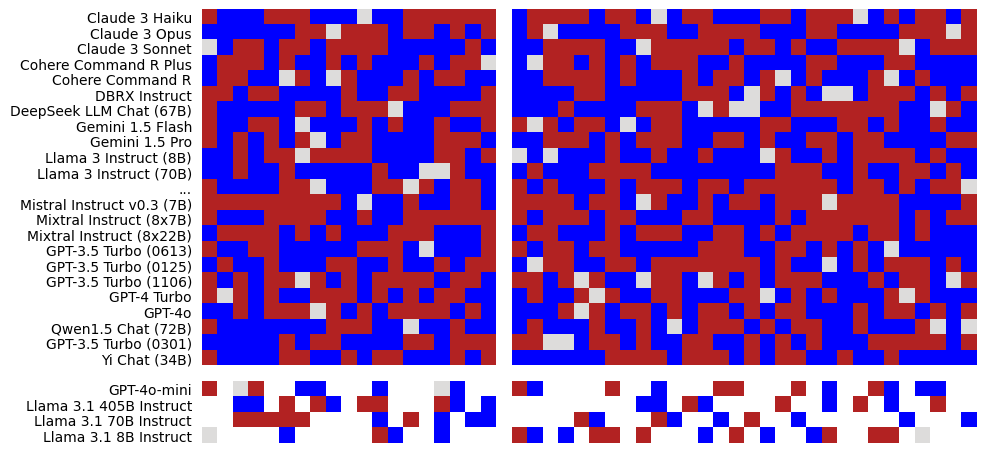

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Set random seed for reproducibility
np.random.seed(42)

# Define the probabilities for each value (-1, 0, 1)
values = [-1, 0, 1]
probabilities_adjusted = [0.05, 0.475, 0.475]  # Adjust probabilities

# Generate the main random matrix (30x50)
matrix_adjusted = np.random.choice(values, size=(30, 50), p=probabilities_adjusted)

# Remove the last 7 rows to make the top matrix 23 rows
matrix_adjusted = matrix_adjusted[:23, :]

# Define model names (some removed for brevity)
filtered_model_names_with_ellipsis = [
    'Claude 3 Haiku', 'Claude 3 Opus', 'Claude 3 Sonnet', 
    'Cohere Command R Plus', 'Cohere Command R', 'DBRX Instruct', 
    'DeepSeek LLM Chat (67B)', 'Gemini 1.5 Flash', 'Gemini 1.5 Pro', 
    'Llama 3 Instruct (8B)', 'Llama 3 Instruct (70B)', '...', 'Mistral Instruct v0.3 (7B)', 
    'Mixtral Instruct (8x7B)', 'Mixtral Instruct (8x22B)', 'GPT-3.5 Turbo (0613)', 
    'GPT-3.5 Turbo (0125)', 'GPT-3.5 Turbo (1106)', 'GPT-4 Turbo', 'GPT-4o', 
    'Qwen1.5 Chat (72B)', 'GPT-3.5 Turbo (0301)', 'Yi Chat (34B)'
]

removed_models_list_updated = [
    'GPT-4o-mini', 'Llama 3.1 405B Instruct', 'Llama 3.1 70B Instruct', 'Llama 3.1 8B Instruct'
]

# Create a new 4x50 matrix for the bottom rows
new_matrix_for_removed_models = np.random.choice(values, size=(4, 50), p=probabilities_adjusted)

# Create a mask to randomly cover 30 positions with white (2) and keep 20 positions colored
mask_corrected_per_row = np.ones_like(new_matrix_for_removed_models) * 2  # Start with all white (2)
for i in range(4):  # For each row, keep 20 random positions
    random_indices_per_row = np.random.choice(50, 20, replace=False)
    mask_corrected_per_row[i, random_indices_per_row] = 0  # Set 0 to keep original colors

# Apply the mask to keep 20 positions per row with the original color and cover the rest with white
new_matrix_for_removed_models_masked_corrected_per_row = np.where(mask_corrected_per_row == 2, 2, new_matrix_for_removed_models)

# Create a white space (1 row) to separate the two matrices using a value of 2 for white
white_space = np.full((1, 50), 2)

# Combine the top and bottom matrices with white space in between
combined_matrix_with_corrected_mask_per_row = np.vstack([matrix_adjusted, white_space, new_matrix_for_removed_models_masked_corrected_per_row])

# Set the 20th column (index 19) to white across both matrices
combined_matrix_with_corrected_mask_per_row[:, 19] = 2  # Set 20th column to white

# Create a colormap that maps -1 to coolwarm, 0 to red, 1 to blue, and 2 to white
cmap_corrected_deeper_red = mcolors.ListedColormap([plt.cm.coolwarm(0.5), 'firebrick', 'blue', 'white'])
bounds_corrected_final = [-1.5, -0.5, 0.5, 1.5, 2.5]
norm_corrected_final = mcolors.BoundaryNorm(bounds_corrected_final, cmap_corrected_deeper_red.N)

# Now recreate the figure
fig, ax = plt.subplots(figsize=(10, 12))

# Plot the matrix with color coding
im = ax.imshow(combined_matrix_with_corrected_mask_per_row, cmap=cmap_corrected_deeper_red, norm=norm_corrected_final)

# Add the final model names (with the removed models at the bottom)
final_model_names_with_space_updated = filtered_model_names_with_ellipsis + [''] + removed_models_list_updated
ax.set_yticks(np.arange(len(final_model_names_with_space_updated)))
ax.set_yticklabels(final_model_names_with_space_updated, fontsize=10)

# Hide x-axis labels but keep y-axis labels (model names)
ax.set_xticks([])

# Remove y-axis ticks and gridlines
ax.tick_params(left=False)

# Remove axis spines and grid lines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display the combined matrix
plt.show()


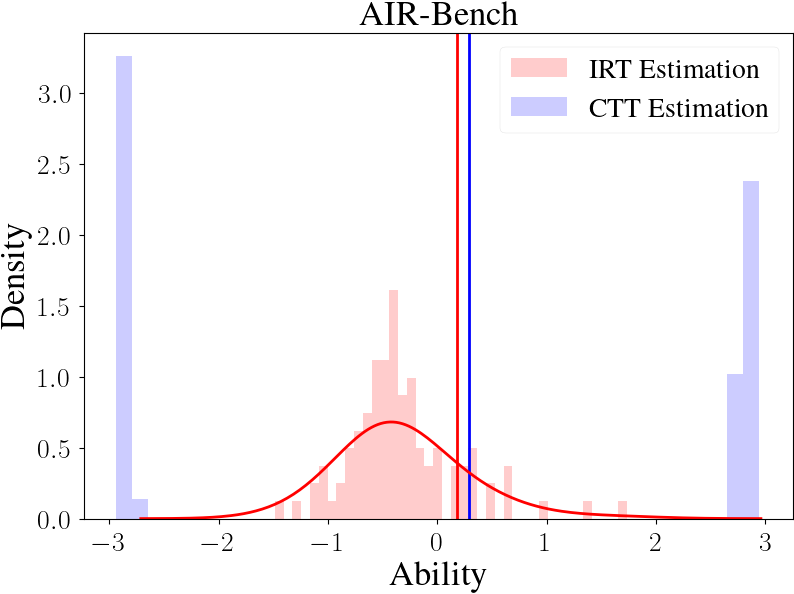

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from tueplots import bundles
plt.rcParams.update(bundles.icml2022())
plt.style.use('seaborn-v0_8-paper')
import numpy as np
import pandas as pd
import torch

df = pd.read_csv('/Users/tyhhh/Desktop/certified-eval/data/hard_easy_test/airbench/airbench_0.csv')
theta_hats_all = df['theta_hat'].values
y_means_all = df['y_mean'].values

response_matrix = pd.read_csv(
        f'../data/pre_calibration/airbench/matrix.csv', index_col=0
    ).values
count_minus_one = np.sum(response_matrix == -1, axis=1)
min_index = np.argmin(count_minus_one)
y = torch.tensor(response_matrix[min_index], dtype=torch.float32)
mask = y != -1

theta = pd.read_csv(
    f'../data/nonamor_calibration/airbench/nonamor_theta.csv'
)["theta"].values[min_index]

z = pd.read_csv(
    f'../data/nonamor_calibration/airbench/nonamor_z.csv'
)["z"].values

plt.figure(figsize=(8, 6))
plt.hist(theta_hats_all, bins=40, color='red', alpha=0.2, label='IRT Estimation', density=True)
plt.hist(y_means_all, bins=40, color='blue', alpha=0.2, label='CTT Estimation', density=True)
plt.axvline(x=theta, color='red', linestyle='-', linewidth=2)
plt.axvline(x=y[mask].mean().item() * 6 - 3, color='blue', linewidth=2)
sns.kdeplot(theta_hats_all, color='red', linewidth=2, bw_adjust=2)
plt.xlabel(r'Ability', fontsize=25)
plt.ylabel(r'Density', fontsize=25)
plt.legend(fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.title('AIR-Bench', fontsize=25)
plt.savefig('../plot/airbench_easy_hard', dpi=300, bbox_inches='tight')

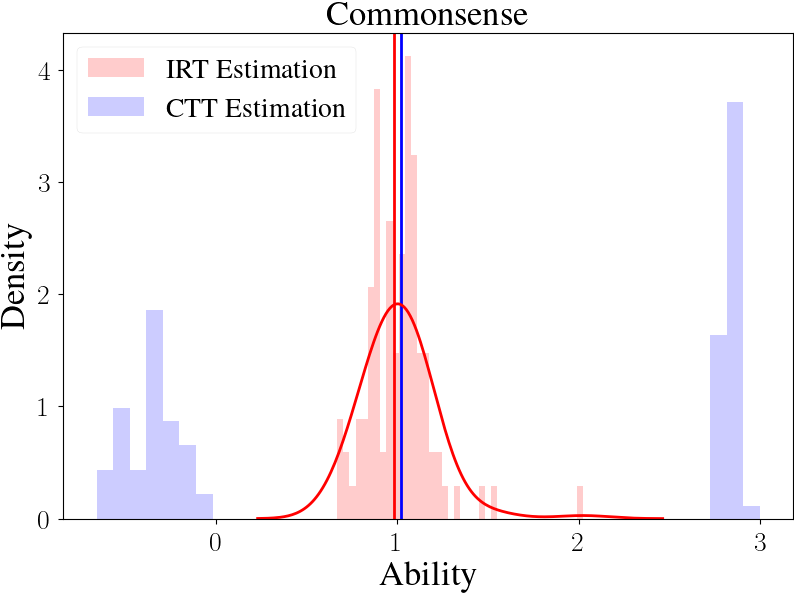

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from tueplots import bundles
plt.rcParams.update(bundles.icml2022())
plt.style.use('seaborn-v0_8-paper')
import numpy as np
import pandas as pd
import torch

df = pd.read_csv('/Users/tyhhh/Desktop/certified-eval/data/hard_easy_test/commonsense/commonsense_0.csv')
theta_hats_all = df['theta_hat'].values
y_means_all = df['y_mean'].values

response_matrix = pd.read_csv(
        f'../data/pre_calibration/commonsense/matrix.csv', index_col=0
    ).values
count_minus_one = np.sum(response_matrix == -1, axis=1)
min_index = np.argmin(count_minus_one)
y = torch.tensor(response_matrix[min_index], dtype=torch.float32)
mask = y != -1

theta = pd.read_csv(
    f'../data/nonamor_calibration/commonsense/nonamor_theta.csv'
)["theta"].values[min_index]

z = pd.read_csv(
    f'../data/nonamor_calibration/commonsense/nonamor_z.csv'
)["z"].values

plt.figure(figsize=(8, 6))
plt.hist(theta_hats_all, bins=40, color='red', alpha=0.2, label='IRT Estimation', density=True)
plt.hist(y_means_all, bins=40, color='blue', alpha=0.2, label='CTT Estimation', density=True)
plt.axvline(x=theta, color='red', linestyle='-', linewidth=2)
plt.axvline(x=y[mask].mean().item() * 6 - 3, color='blue', linewidth=2)
sns.kdeplot(theta_hats_all, color='red', linewidth=2, bw_adjust=2)
plt.xlabel(r'Ability', fontsize=25)
plt.ylabel(r'Density', fontsize=25)
plt.legend(fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.title('Commonsense', fontsize=25)
plt.savefig('../plot/commonsense_easy_hard', dpi=300, bbox_inches='tight')

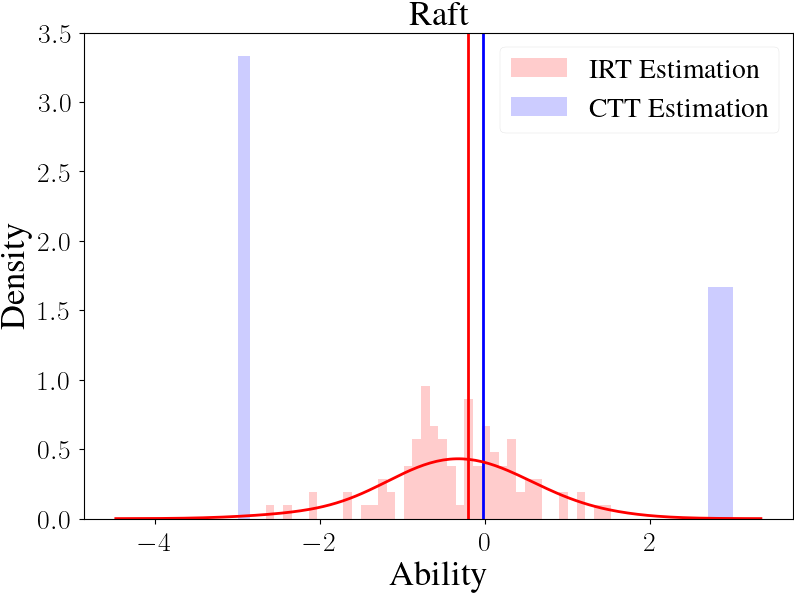

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from tueplots import bundles
plt.rcParams.update(bundles.icml2022())
plt.style.use('seaborn-v0_8-paper')
import numpy as np
import pandas as pd
import torch

df = pd.read_csv('/Users/tyhhh/Desktop/certified-eval/data/hard_easy_test/raft/raft_0.csv')
theta_hats_all = df['theta_hat'].values
y_means_all = df['y_mean'].values

response_matrix = pd.read_csv(
        f'../data/pre_calibration/raft/matrix.csv', index_col=0
    ).values
count_minus_one = np.sum(response_matrix == -1, axis=1)
min_index = np.argmin(count_minus_one)
y = torch.tensor(response_matrix[min_index], dtype=torch.float32)
mask = y != -1

theta = pd.read_csv(
    f'../data/nonamor_calibration/raft/nonamor_theta.csv'
)["theta"].values[min_index]

z = pd.read_csv(
    f'../data/nonamor_calibration/raft/nonamor_z.csv'
)["z"].values

plt.figure(figsize=(8, 6))
plt.hist(theta_hats_all, bins=40, color='red', alpha=0.2, label='IRT Estimation', density=True)
plt.hist(y_means_all, bins=40, color='blue', alpha=0.2, label='CTT Estimation', density=True)
plt.axvline(x=theta, color='red', linestyle='-', linewidth=2)
plt.axvline(x=y[mask].mean().item() * 6 - 3, color='blue', linewidth=2)
sns.kdeplot(theta_hats_all, color='red', linewidth=2, bw_adjust=2)
plt.xlabel(r'Ability', fontsize=25)
plt.ylabel(r'Density', fontsize=25)
plt.legend(fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.title('Raft', fontsize=25)
plt.savefig('../plot/raft_easy_hard', dpi=300, bbox_inches='tight')